In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import pickle
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings("ignore")

# Load featured data
df = pd.read_csv("../data/featured_sample.csv")
df['date'] = pd.to_datetime(df['date'])

print("Data loaded successfully!")
print("Shape:", df.shape)

Data loaded successfully!
Shape: (500000, 32)


In [3]:
# Prepare features
feature_cols = ['month', 'year', 'wday', 'day', 'week', 'quarter',
                'is_weekend', 'is_month_start', 'is_month_end',
                'has_event', 'is_snap', 'avg_price',
                'sales_lag_1', 'sales_lag_7', 'sales_lag_28',
                'sales_rolling_7', 'sales_rolling_28']

df['cat_encoded'] = df['cat_id'].astype('category').cat.codes
df['store_encoded'] = df['store_id'].astype('category').cat.codes
df['state_encoded'] = df['state_id'].astype('category').cat.codes

feature_cols = feature_cols + ['cat_encoded', 'store_encoded', 'state_encoded']

X = df[feature_cols]
y = df['sales']

train_mask = df['date'] < '2016-01-01'
test_mask = df['date'] >= '2016-01-01'

X_train = X[train_mask]
X_test = X[test_mask]
y_train = y[train_mask]
y_test = y[test_mask]

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (469976, 20)
Testing set: (30024, 20)


In [4]:
# Train Linear Regression Model
print("Training Linear Regression model...")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
y_pred_lr = np.maximum(y_pred_lr, 0)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression trained!")
print("MAE:", round(mae_lr, 2))
print("RMSE:", round(rmse_lr, 2))

Training Linear Regression model...
Linear Regression trained!
MAE: 1.2
RMSE: 2.5


In [5]:
# Train Random Forest Model (using a smaller sample for speed)
print("Training Random Forest model...")

# Use sample for faster training
sample_idx = np.random.choice(len(X_train), size=100000, replace=False)
X_train_sample = X_train.iloc[sample_idx]
y_train_sample = y_train.iloc[sample_idx]

rf_model = RandomForestRegressor(
    n_estimators=100, max_depth=10, random_state=42, n_jobs=-1
)
rf_model.fit(X_train_sample, y_train_sample)

y_pred_rf = rf_model.predict(X_test)
y_pred_rf = np.maximum(y_pred_rf, 0)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest trained!")
print("MAE:", round(mae_rf, 2))
print("RMSE:", round(rmse_rf, 2))

Training Random Forest model...
Random Forest trained!
MAE: 1.21
RMSE: 2.47


FINAL MODEL COMPARISON
               Model    MAE   RMSE
4  Advanced LightGBM   1.18   2.46
1  Linear Regression   1.20   2.50
3     Basic LightGBM   1.20   2.49
2      Random Forest   1.21   2.47
0            Prophet  12.00  17.04


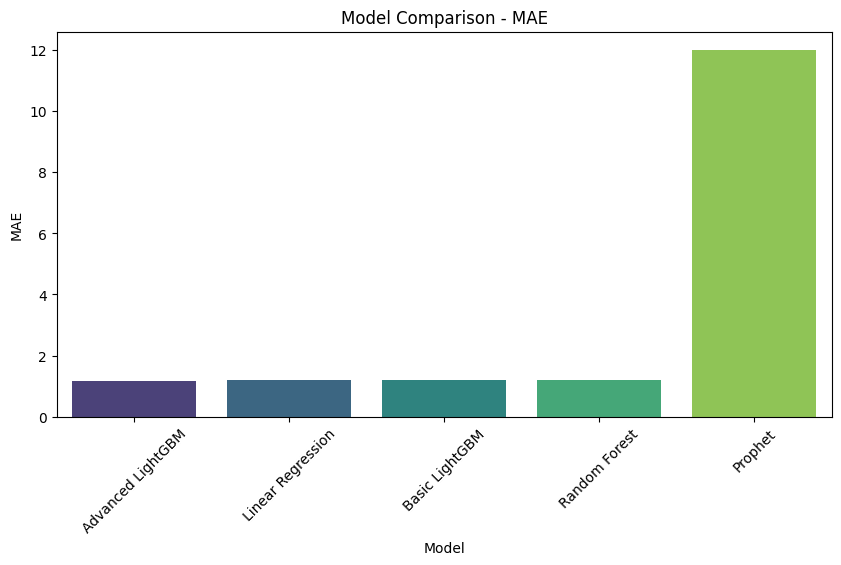


Best Model: Advanced LightGBM with MAE 1.18
Model comparison saved!


In [6]:
# Final Model Comparison
model_comparison = pd.DataFrame({
    'Model': ['Prophet', 'Linear Regression', 'Random Forest', 
              'Basic LightGBM', 'Advanced LightGBM'],
    'MAE': [12.0, round(mae_lr, 2), round(mae_rf, 2), 1.2, 1.18],
    'RMSE': [17.04, round(rmse_lr, 2), round(rmse_rf, 2), 2.49, 2.46]
})

model_comparison = model_comparison.sort_values('MAE')

print("FINAL MODEL COMPARISON")
print("="*50)
print(model_comparison)
print("="*50)

# Plot comparison
plt.figure(figsize=(10,5))
sns.barplot(x='Model', y='MAE', data=model_comparison, palette='viridis')
plt.title("Model Comparison - MAE")
plt.xticks(rotation=45)
plt.show()

# Save comparison
model_comparison.to_csv("../data/final_model_comparison.csv", index=False)

print("\nBest Model: Advanced LightGBM with MAE 1.18")
print("Model comparison saved!")